Discretizing features | CV: statistical | BMI: clinical | HbA1c: clinical | Glucose: clinical
   - preExerciseGlucoseCV thresholds: [ 0.55948714 10.32391018 18.86776755 68.63304324]
Discretization complete.

🔨 Collapsing sparse bins to optimize the Bayesian Network...


/Users/albertogastaldello/Desktop/PAxT1D_BN/LOOP_repo/utils.py:379: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  clean_df['BMI'] = clean_df['BMI'].replace(
/Users/albertogastaldello/Desktop/PAxT1D_BN/LOOP_repo/utils.py:388: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  clean_df['startExerciseGlucoseLevel'] = clean_df['startExerciseGlucoseLevel'].replace(


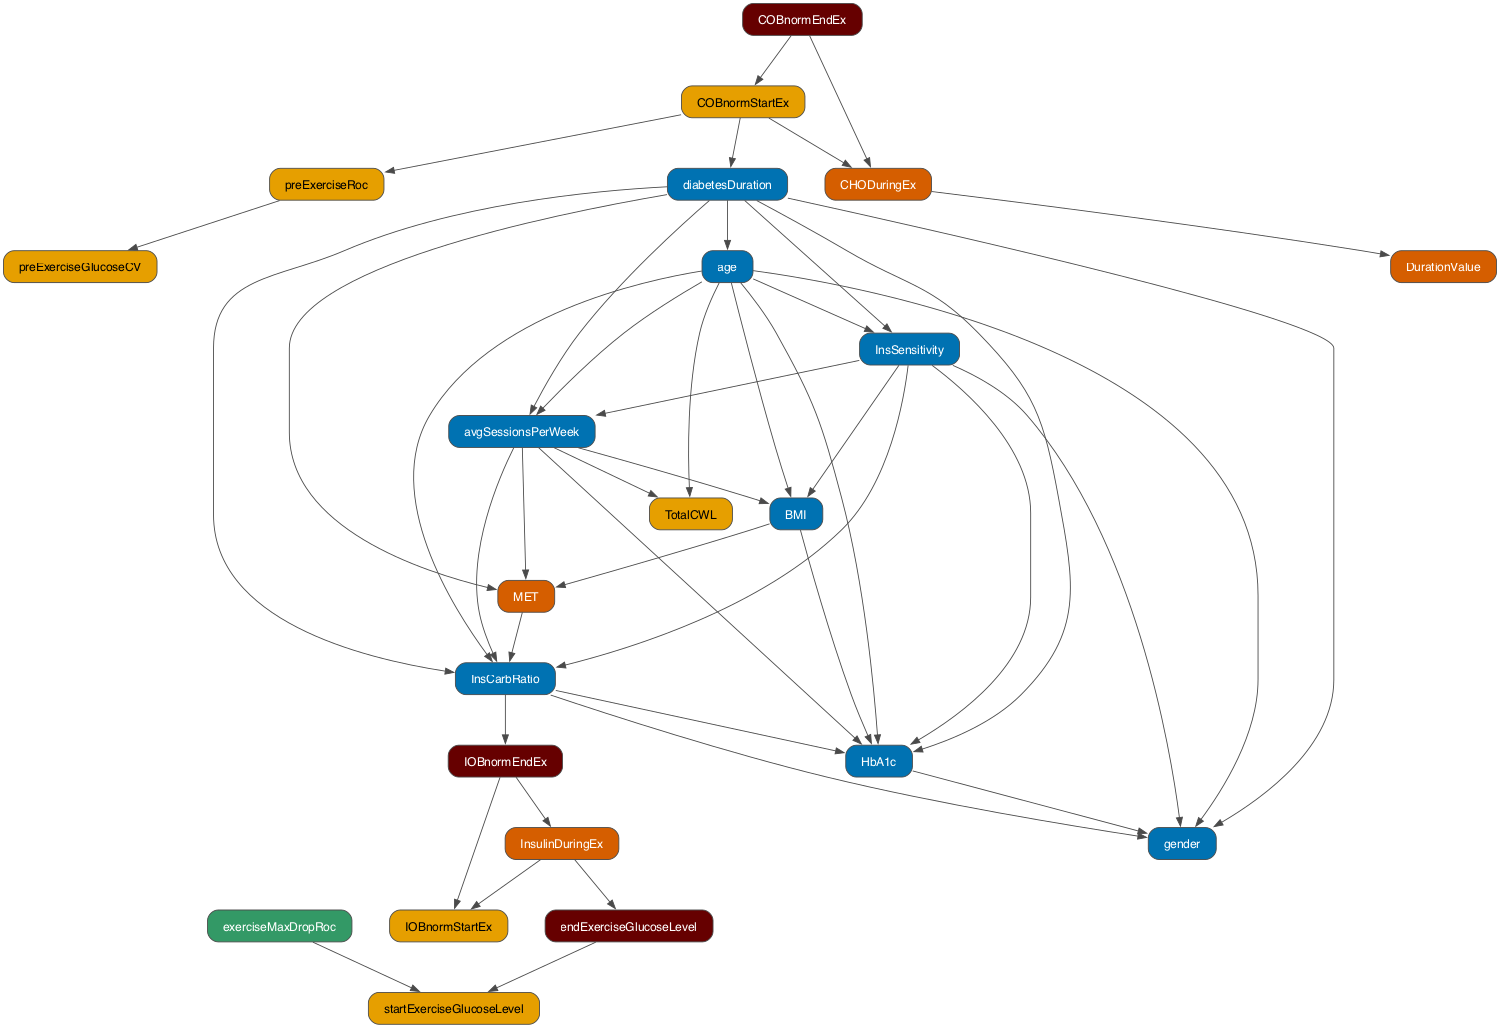

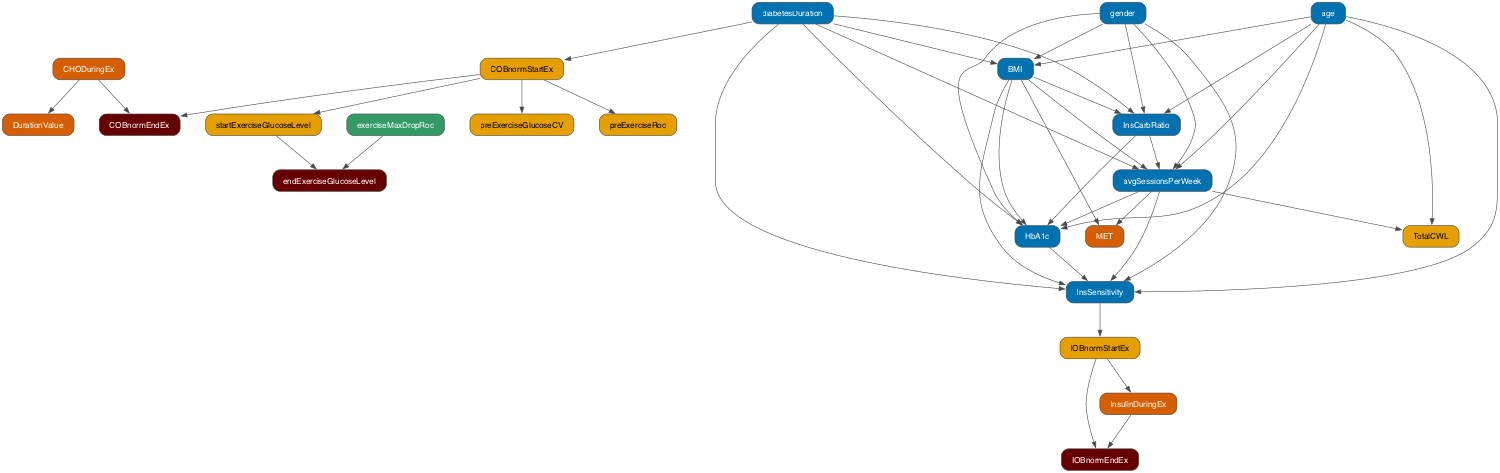

In [2]:
from utils import *
import pandas as pd
import os
import numpy as np


# load data 
file_path = os.path.join("tables", "exerciseTableForBN_python_processed.csv")
exerciseTable = pd.read_csv(file_path)

df_running = exerciseTable[exerciseTable['CleanActivityName'] == 'Running']
df = df_running[(df_running['DurationValue'] >= 20) & (df_running['DurationValue'] <= 90)]


tiers = {
        'static': ['age', 'gender', 'diabetesDuration', 'BMI', 'HbA1c', 'InsSensitivity', 'InsCarbRatio', 'avgSessionsPerWeek'],
        'pre': ['preExerciseRoc', 'startExerciseGlucoseLevel', 'preExerciseGlucoseCV', 'IOBnormStartEx', 'COBnormStartEx', 'TotalCWL'],
        'exercise' : ['MET', 'DurationValue', 'CHODuringEx', 'InsulinDuringEx'],
        'end_exercise' : ['endExerciseGlucoseLevel', 'IOBnormEndEx', 'COBnormEndEx'],
        'outcome_during': ['exerciseMaxDropRoc'],
        'outcome_post': []
        #'exercise' : ['MET_min', 'ExerciseModality'],
        #'outcome_during': ['exerciseNadir'],
        #'outcome_post': ['postExerciseHypoEvent']
    }

all_features = exerciseTable.columns.tolist()
features_to_drop = set(all_features) - set(sum(tiers.values(), []))


df_discrete = discretize_data(df, 
    cv_strategy = "statistical",
    bmi_strategy = "clinical",
    hba1c_strategy = "clinical", 
    glucose_strategy = "clinical", 
    roc_strategy = "clinical",
    cols_to_remove = features_to_drop)

df_discrete_collapsed = collapse_sparse_bins(df_discrete)
# Data Driven BN

collapse = True

if(collapse):
    learner_data_driven = gum.BNLearner(df_discrete_collapsed)
else:
    learner_data_driven = gum.BNLearner(df_discrete)

learner_data_driven.useGreedyHillClimbing()
bn_data_driven = learner_data_driven.learnBN()

visualize_network(bn_data_driven, tiers)


# Constrained BN

collapse = True

if(collapse):
    learner_constrained = gum.BNLearner(df_discrete_collapsed)
else:
    learner_constrained = gum.BNLearner(df_discrete)
    
learner_constrained.useGreedyHillClimbing()
learner_constrained = apply_expert_constraints(learner_constrained, tiers)
bn_constrained = learner_constrained.learnBN()

visualize_network(bn_constrained, tiers)



In [ ]:

import pyagrum as gum
import matplotlib.pyplot as plt

def plot_feature_importance(bn, target_node, threshold=0.001):
    """
    Calculates and plots the Mutual Information (Feature Importance) 
    for a given target node in a Bayesian Network.
    """
    # 1. Initialize the inference engine
    ie = gum.LazyPropagation(bn)
    
    # 2. Calculate Mutual Information for all nodes relative to the target
    mi_dict = {}
    for node in bn.names():
        if node != target_node:
            it = gum.InformationTheory(ie, target_node, node)
            mi = it.mutualInformationXY()
            mi_dict[node] = mi
            
    # 3. Sort the dictionary by importance
    sorted_mi = dict(sorted(mi_dict.items(), key=lambda item: item[1], reverse=True))
    
    # 4. Filter out features with near-zero importance to keep the chart clean
    filtered_mi = {k: v for k, v in sorted_mi.items() if v > threshold}
    
    if not filtered_mi:
        print(f"No features found with importance > {threshold}")
        return
        
    # 5. Prepare data for plotting 
    # (We reverse the lists so the highest value sits at the top of the horizontal chart)
    features = list(filtered_mi.keys())[::-1]
    importances = list(filtered_mi.values())[::-1]
    
    # 6. Generate the Plot using your Okabe-Ito Vermillion color
    plt.figure(figsize=(10, max(6, len(features) * 0.4)))
    bars = plt.barh(features, importances, color='#D55E00', edgecolor='black')
    
    plt.xlabel('Mutual Information (Bits / Entropy Reduction)', fontsize=12)
    plt.title(f'Feature Importance for: {target_node}', fontsize=14, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()
    
    print(f"--- Exact Mutual Information Scores for '{target_node}' ---")
    for feat, score in filtered_mi.items():
        print(f"{feat}: {score:.4f} bits")


# Use the function to plot feature importance for the target node of interest

plot_feature_importance(bn_constrained, target_node='exerciseMaxDropRoc')



In [ ]:

interactive_inference_dashboard(
    bn = bn_constrained, 
    evidence_nodes = [ 'InsulinDuringEx', 'startExerciseGlucoseLevel'], 
    target_node = 'endExerciseGlucoseLevel'
)


import pyagrum as gum

# 1. Initialize the Inference Engine
ie = gum.LazyPropagation(bn_constrained) # Or use VariableElimination(bn)

# 2. Fix the Evidence: Set the outcome to 1 (Hypo happens)
# Ensure 'postExerciseHypoEvent' is the exact name in your BN
ie.setEvidence({'postExerciseHypoEvent': 1})

# 3. Run Inference
ie.makeInference()

# 4. Extract the Posterior Beliefs for variables of interest
# Example: What is the distribution of starting glucose now that we know they crashed?
posterior_glucose = ie.posterior('startExerciseGlucoseLevel')
print("Posterior distribution of glucose given a Hypo event:")
print(posterior_glucose)

# 5. Compare with Prior (Baseline)
# Run inference without evidence to get priors, then compare against posterior